# Loss Function 설계 — Smoothed Edge-Preserving RD Loss

**담당:** Loss Function 설계 / **주차:** 3주차 (Edge Loss 수학적 구현 및 테스트)

이 노트북은 "Ours" 모델의 최종 손실 함수를 구현하고 검증합니다.

$$\mathcal{L}_{total} = R_{bpp} \;+\; \lambda \cdot 255^2 \cdot \text{MSE}(\hat{x}, y) \;+\; \beta \cdot \mathcal{L}_{edge}^{smooth}(\hat{x}, y)$$

| 항 | 의미 | 역할 |
|---|---|---|
| $R_{bpp}$ | Bits Per Pixel (엔트로피) | 압축량 최소화 (Rate) |
| $\text{MSE}$ | 픽셀 오차 | 밝기/색 복원 (Distortion) |
| $\mathcal{L}_{edge}^{smooth}$ | **Sobel + Gaussian blur 엣지 손실** | **윤곽선 보존** |

**핵심 아이디어:** Sobel로 윤곽선을 뽑되, 엣지 맵을 Gaussian으로 흐려서 비교한다.
→ LOL Pair의 1~3px 미세 어긋남(misalignment)이 만드는 ghosting 페널티를 흡수 → 윤곽선만 안정적으로 학습.

---
### 📌 이번 개선 (2가지 문제 해결)

**문제 1 — 손실 항 스케일 불균형** → **§3-2**
MSE 항의 실효 계수가 `λ·255² ≈ 227.6`으로 압도적이라, Edge 항이 전체의 1% 미만만 기여했습니다.
→ 실제 데이터에서 각 항 크기를 **측정**하고 `edge_weight`를 **자동 보정**(`calibrate_edge_weight`)합니다.

**문제 2 — MSE 항이 pixel 어긋남에 무방비** → **§3**
Edge 항만 blur로 보호했고 MSE는 그대로라, 어긋난 pair에서 "평균 예측 = 뭉갬"을 유발했습니다.
→ `mse_blur_sigma` 옵션 추가. **기본값 0이면 기존과 100% 동일**하고, 켤 때만 MSE도 관대해집니다.

In [1]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", device)

device: cuda


## 1. Sobel Edge Magnitude — 윤곽선 추출

Sobel 커널로 가로/세로 방향 밝기 변화율(gradient)을 구하고, 크기(magnitude)를 윤곽선 맵으로 씁니다.

$$G_x = K_x * I,\quad G_y = K_y * I,\quad E(I) = \sqrt{G_x^2 + G_y^2 + \epsilon}$$

$$K_x = \begin{bmatrix} -1 & 0 & 1 \\ -2 & 0 & 2 \\ -1 & 0 & 1 \end{bmatrix},\quad K_y = K_x^\top$$

- 컬러 대신 **밝기(grayscale)** 채널에서 엣지를 뽑는 게 표준이고 가볍습니다 (구조=윤곽에 집중).
- `sqrt` 안의 $\epsilon$은 gradient가 0일 때 역전파 NaN을 막는 안전장치.

In [2]:
def rgb_to_gray(x):
    """N,3,H,W (0~1) -> N,1,H,W  (ITU-R BT.601 luminance)"""
    r, g, b = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b

def make_sobel():
    kx = torch.tensor([[-1., 0., 1.],
                       [-2., 0., 2.],
                       [-1., 0., 1.]])
    ky = kx.t().contiguous()
    return kx.view(1, 1, 3, 3), ky.view(1, 1, 3, 3)

SOBEL_X, SOBEL_Y = make_sobel()

def edge_magnitude(x, sobel_x, sobel_y, eps=1e-6, use_gray=True):
    """윤곽선(gradient magnitude) 맵을 반환. x: N,3,H,W (0~1)"""
    if use_gray:
        x = rgb_to_gray(x)
    C = x.shape[1]
    sx = sobel_x.to(x.device).repeat(C, 1, 1, 1)
    sy = sobel_y.to(x.device).repeat(C, 1, 1, 1)
    gx = F.conv2d(x, sx, padding=1, groups=C)
    gy = F.conv2d(x, sy, padding=1, groups=C)
    return torch.sqrt(gx ** 2 + gy ** 2 + eps)

print("✅ Sobel 엣지 추출 함수 준비 완료")

✅ Sobel 엣지 추출 함수 준비 완료


### 1-1. 시각 확인 — 합성 이미지로 엣지 맵 뽑아보기
(실제 LOL 이미지가 없어도 되도록, 여기선 원/사각형 합성 이미지로 검증합니다.)

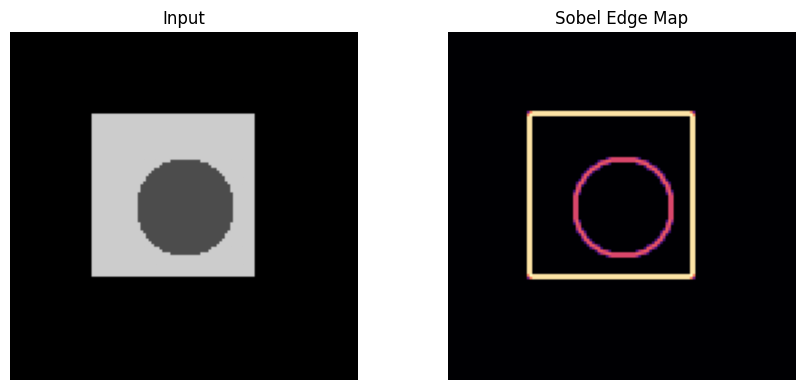

In [3]:
def make_synthetic(H=128, W=128):
    """가운데 밝은 사각형 + 원이 있는 테스트 이미지 (N=1,3,H,W)"""
    img = torch.zeros(1, 3, H, W)
    img[:, :, 30:90, 30:90] = 0.8          # 사각형
    yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
    circle = ((yy - 64) ** 2 + (xx - 64) ** 2) < 18 ** 2
    img[:, :, circle] = 0.3
    return img

sample = make_synthetic()
emap = edge_magnitude(sample, SOBEL_X, SOBEL_Y)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(sample[0].permute(1, 2, 0)); ax[0].set_title("Input"); ax[0].axis('off')
ax[1].imshow(emap[0, 0], cmap='magma'); ax[1].set_title("Sobel Edge Map"); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 2. 왜 "Smoothed"(Gaussian blur)인가 — Misalignment/Ghosting 문제

LOL 데이터셋의 low/high Pair는 촬영·정합 과정에서 **1~3픽셀 미세하게 어긋나** 있습니다.
- 날카로운 엣지 맵을 그대로 L1 비교하면, 모델이 **정답을 완벽히 복원해도** 1px 어긋난 위치의 엣지가 겹치지 않아 **큰 페널티(이중 윤곽 = ghosting)**를 받습니다.
- 해결: 엣지 맵에 **Gaussian blur**를 먹여 공간적으로 살짝 퍼뜨리면, 몇 px 어긋나도 엣지가 겹쳐 → 손실이 **미세 정렬 오차에 둔감(robust)** 해집니다.

$$\mathcal{L}_{edge}^{smooth}(\hat{x}, y) = \big\| \; G_\sigma * E(\hat{x}) \; - \; G_\sigma * E(y) \; \big\|_1$$

$G_\sigma$ = Gaussian blur 커널. $\sigma$가 클수록 어긋남에 관대하지만 윤곽이 뭉개지므로 trade-off.

In [4]:
def gaussian_kernel(ksize=5, sigma=1.0):
    ax = torch.arange(ksize) - ksize // 2
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    k = torch.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return (k / k.sum()).view(1, 1, ksize, ksize)

def blur(x, gk):
    C = x.shape[1]
    g = gk.to(x.device).repeat(C, 1, 1, 1)
    pad = gk.shape[-1] // 2
    return F.conv2d(x, g, padding=pad, groups=C)

print("✅ Gaussian blur 준비 완료")

✅ Gaussian blur 준비 완료


### 2-1. 검증 실험 — "정답을 1~5px 옮겨가며" 손실이 어떻게 변하나
완벽 복원(shift=0)일 때 손실이 0에 가깝고, 어긋남이 커질수록 완만히 오르는 게 이상적입니다.
**Sharp Edge Loss(blur X)**는 1px만 어긋나도 급등하고, **Smoothed(blur O)**는 완만합니다.

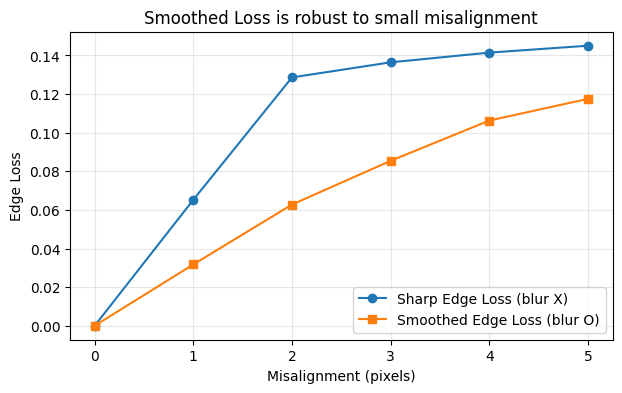

shift=1px  ->  sharp: 0.0653 | smooth: 0.0317
→ smooth 쪽이 1px 어긋남에서 페널티가 훨씬 작으면 설계 의도대로 동작하는 것 ✅


In [5]:
gk = gaussian_kernel(ksize=7, sigma=1.5)

target = make_synthetic()
target_edge = edge_magnitude(target, SOBEL_X, SOBEL_Y)

shifts = list(range(0, 6))
sharp_losses, smooth_losses = [], []
for s in shifts:
    # 정답을 s픽셀 옆으로 민 것을 '완벽하지만 살짝 어긋난 예측'으로 가정
    pred = torch.roll(target, shifts=s, dims=3)
    pred_edge = edge_magnitude(pred, SOBEL_X, SOBEL_Y)

    sharp = F.l1_loss(pred_edge, target_edge).item()
    smooth = F.l1_loss(blur(pred_edge, gk), blur(target_edge, gk)).item()
    sharp_losses.append(sharp)
    smooth_losses.append(smooth)

plt.figure(figsize=(7, 4))
plt.plot(shifts, sharp_losses, 'o-', label='Sharp Edge Loss (blur X)')
plt.plot(shifts, smooth_losses, 's-', label='Smoothed Edge Loss (blur O)')
plt.xlabel('Misalignment (pixels)'); plt.ylabel('Edge Loss')
plt.title('Smoothed Loss is robust to small misalignment')
plt.legend(); plt.grid(alpha=0.3); plt.show()

print("shift=1px  ->  sharp: %.4f | smooth: %.4f" % (sharp_losses[1], smooth_losses[1]))
print("→ smooth 쪽이 1px 어긋남에서 페널티가 훨씬 작으면 설계 의도대로 동작하는 것 ✅")

## 3. 최종 Loss 모듈 — `RateDistortionEdgeLoss`

**이 셀이 하는 일:** CompressAI 모델의 출력(`out_net`)과 정답 `y`를 받아 세 항(BPP + MSE + Edge)을 합치는 최종 손실 모듈을 정의합니다.

이번에 두 가지가 추가되었습니다.

**① `mse_blur_sigma` 옵션 (문제 2 대응)**
MSE 항도 pixel 어긋남에 관대해질 수 있게 하는 스위치입니다.
- `0` (**기본값**) → 지금까지와 **100% 똑같은 순수 MSE**. 기존 실험 결과가 절대 바뀌지 않습니다.
- `> 0` → MSE 계산 직전에 `x_hat`과 `target` **양쪽을 똑같은 Gaussian으로 살짝 흐린 뒤** 비교 → 1~3px 어긋남에 관대해짐.

> ⚠️ **Ablation 규율:** 기본 실험(Baseline 3, Ours)은 반드시 `mse_blur_sigma=0`으로 돌립니다.
> MSE-blur는 "나중에 켜서 추가 실험만" 하는 **옵션**이지, 기본 설정이 아닙니다.

**② `logs`에 실효 크기와 설정값 기록 (문제 1 대응)**
- `distortion_term` = `lmbda·255²·mse` (MSE 항의 **실제 크기**)
- `edge_term` = `edge_weight·edge` (Edge 항의 **실제 크기**)
- `edge_weight`, `mse_blur_sigma` (현재 설정값)

이 값들이 있어야 §3-2에서 "어느 항이 얼마나 세게 작용하는지" 측정할 수 있습니다.

In [6]:
class SmoothedEdgeLoss(nn.Module):
    # ※ 기존과 동일 — 건드리지 않음 (재사용만)
    def __init__(self, blur_ksize=7, blur_sigma=1.5, use_gray=True, eps=1e-6):
        super().__init__()
        kx, ky = make_sobel()
        self.register_buffer('sobel_x', kx)
        self.register_buffer('sobel_y', ky)
        self.register_buffer('gauss', gaussian_kernel(blur_ksize, blur_sigma))
        self.use_gray = use_gray
        self.eps = eps

    def forward(self, pred, target):
        e_pred = edge_magnitude(pred, self.sobel_x, self.sobel_y, self.eps, self.use_gray)
        e_tgt  = edge_magnitude(target, self.sobel_x, self.sobel_y, self.eps, self.use_gray)
        return F.l1_loss(blur(e_pred, self.gauss), blur(e_tgt, self.gauss))


class RateDistortionEdgeLoss(nn.Module):
    """Ours 최종 손실: BPP + lambda*255^2*MSE + edge_weight*SmoothedEdge

    [변경점 1] mse_blur_sigma 인자 추가 (문제 2: MSE가 pixel 어긋남에 무방비)
        - 0 (기본값): 기존과 완전히 동일한 순수 MSE. -> 기준 실험 불변 보장
        - > 0       : MSE 계산 전에 x_hat/target 양쪽을 같은 Gaussian으로 흐림
                      -> LOL pair의 1~3px 어긋남에 관대해져 '평균 예측=뭉갬'을 완화
    [변경점 2] logs에 각 항의 '실효 크기'와 현재 설정값을 기록 (문제 1: 스케일 측정용)
    """
    def __init__(self, lmbda=0.0035, edge_weight=0.1,
                 blur_ksize=7, blur_sigma=1.5, use_gray=True,
                 mse_blur_sigma=0.0, mse_blur_ksize=None):
        super().__init__()
        self.lmbda = lmbda
        self.edge_weight = edge_weight
        self.mse = nn.MSELoss()
        self.edge = SmoothedEdgeLoss(blur_ksize, blur_sigma, use_gray)   # 기존 모듈 재사용

        # --- [변경점 1] MSE 용 Gaussian 커널 준비 ---
        # sigma=0 이면 커널을 아예 만들지 않음(None) -> forward에서 순수 MSE 경로를 탐
        self.mse_blur_sigma = float(mse_blur_sigma)
        if self.mse_blur_sigma > 0:
            if mse_blur_ksize is None:
                # 커널 크기를 sigma로부터 자동 결정 (약 6σ, 항상 홀수)
                mse_blur_ksize = int(2 * math.ceil(3 * self.mse_blur_sigma) + 1)
            # 기존 gaussian_kernel 재사용 + 기존 register_buffer 패턴 유지
            self.register_buffer('mse_gauss', gaussian_kernel(int(mse_blur_ksize), self.mse_blur_sigma))
        else:
            # None 버퍼: .to(device) 해도 안전하고, "꺼짐"을 명시적으로 표현
            self.register_buffer('mse_gauss', None)

    def forward(self, out_net, target):
        x_hat = out_net['x_hat']
        N, _, H, W = target.size()
        num_pixels = N * H * W

        # --- Rate 항: 압축량(BPP) ---
        bpp = sum(
            (torch.log(l).sum() / (-math.log(2) * num_pixels))
            for l in out_net['likelihoods'].values()
        )

        # --- Distortion 항: MSE ---
        if self.mse_gauss is not None:
            # [옵션 경로] 양쪽을 '똑같은' blur로 흐린 뒤 MSE -> 미세 어긋남에 관대
            # (blur는 손실 계산에만 쓰이며, 모델 출력 이미지 자체는 흐려지지 않음)
            mse_val = self.mse(blur(x_hat, self.mse_gauss), blur(target, self.mse_gauss))
        else:
            # [기본 경로] mse_blur_sigma=0 -> 기존과 한 글자도 다르지 않은 순수 MSE
            mse_val = self.mse(x_hat, target)

        # --- Edge 항: 윤곽선 보존 ---
        edge_val = self.edge(x_hat, target)

        # --- 각 항의 '실효 크기' (계수를 곱한 뒤의 실제 기여분) ---
        distortion_term = self.lmbda * (255 ** 2) * mse_val   # 기본값 기준 약 227.6 * mse
        edge_term = self.edge_weight * edge_val

        loss = bpp + distortion_term + edge_term

        return loss, {
            'loss': loss.item(),
            'bpp': bpp.item(),
            'mse': mse_val.item(),                       # 계수 곱하기 전 원본 값
            'edge': edge_val.item(),                     # 계수 곱하기 전 원본 값
            # [변경점 2] 스케일 측정을 위한 실효 크기 + 현재 설정값
            'distortion_term': distortion_term.item(),   # = lmbda*255^2*mse
            'edge_term': edge_term.item(),               # = edge_weight*edge
            'edge_weight': float(self.edge_weight),
            'mse_blur_sigma': float(self.mse_blur_sigma),
        }

print("✅ RateDistortionEdgeLoss 모듈 준비 완료 (mse_blur_sigma 옵션 추가)")

✅ RateDistortionEdgeLoss 모듈 준비 완료 (mse_blur_sigma 옵션 추가)


### 3-1. 동작·역전파 테스트 (가짜 out_net으로)

**이 셀이 하는 일:** CompressAI 모델이나 실제 데이터 없이, 가짜 출력만으로 손실 함수가 제대로 도는지 빠르게 검사합니다.

세 가지를 확인합니다.
1. **기본값(`mse_blur_sigma=0`)에서 gradient가 흐르는가** — 학습 가능 여부
2. **`mse_blur_sigma>0`에서도 gradient가 흐르는가** — 새 옵션이 망가지지 않았는가
3. ⭐ **기본값 경로가 순수 MSE와 완전히 똑같은가** — `assert`로 검증
   → 이게 통과해야 "기존 실험 결과가 안 바뀐다"를 보장할 수 있습니다 (ablation 규율)

In [7]:
# 가짜 출력으로 스모크 테스트: x_hat 은 학습 대상(requires_grad)
torch.manual_seed(0)
y = make_synthetic().to(device)

def make_fake_out_net():
    """매 테스트마다 새 x_hat(grad 초기화된)과 가짜 likelihoods를 만들어 줌"""
    x_hat = (y + 0.05 * torch.randn_like(y)).clamp(0, 1).detach().requires_grad_(True)
    fake_likelihoods = {
        'y': torch.rand(1, 8, 16, 16, device=device).clamp(1e-6, 1),
        'z': torch.rand(1, 4, 8, 8, device=device).clamp(1e-6, 1),
    }
    return x_hat, {'x_hat': x_hat, 'likelihoods': fake_likelihoods}


# ---------- [테스트 1] 기본값 (mse_blur_sigma=0) : 기존 동작 ----------
torch.manual_seed(0)
x_hat_a, out_net_a = make_fake_out_net()
criterion = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=0.1).to(device)  # mse_blur_sigma=0
loss_a, logs_a = criterion(out_net_a, y)
loss_a.backward()

print("[1] mse_blur_sigma=0 (기본)")
print("    logs:", {k: round(v, 5) for k, v in logs_a.items()})
print("    grad 흐름:", x_hat_a.grad is not None, "| grad mean:", x_hat_a.grad.abs().mean().item())

# ⭐ 핵심 검증: 기본 경로가 '순수 MSE'와 수치적으로 완전히 동일한가?
#    (다르면 ablation 기준 실험이 바뀌어 버리므로 반드시 통과해야 함)
pure_mse = F.mse_loss(x_hat_a.detach(), y).item()
assert abs(logs_a['mse'] - pure_mse) < 1e-9, "❌ 기본 경로가 순수 MSE와 다릅니다!"
print("    ✅ 기본 경로 == 순수 MSE (기존 실험 결과 불변 보장)")


# ---------- [테스트 2] 옵션 켬 (mse_blur_sigma>0) : 새 경로 ----------
torch.manual_seed(0)
x_hat_b, out_net_b = make_fake_out_net()
criterion_blur = RateDistortionEdgeLoss(lmbda=0.0035, edge_weight=0.1,
                                        mse_blur_sigma=1.0).to(device)
loss_b, logs_b = criterion_blur(out_net_b, y)
loss_b.backward()

print("\n[2] mse_blur_sigma=1.0 (옵션 켬)")
print("    logs:", {k: round(v, 5) for k, v in logs_b.items()})
print("    grad 흐름:", x_hat_b.grad is not None, "| grad mean:", x_hat_b.grad.abs().mean().item())

assert x_hat_b.grad is not None and torch.isfinite(x_hat_b.grad).all(), "❌ blur 경로 gradient 이상"
assert logs_b['mse'] != logs_a['mse'], "❌ blur를 켰는데 MSE가 그대로입니다"
print("    ✅ blur 경로도 gradient 정상 (blur를 켜니 MSE 값이 달라짐 = 의도대로 동작)")

print("\n🎉 스모크 테스트 전부 통과")

[1] mse_blur_sigma=0 (기본)
    logs: {'loss': 0.5639, 'bpp': 0.20929, 'mse': 0.00152, 'edge': 0.08657, 'distortion_term': 0.34596, 'edge_term': 0.00866, 'edge_weight': 0.1, 'mse_blur_sigma': 0.0}
    grad 흐름: True | grad mean: 0.0002312422584509477
    ✅ 기본 경로 == 순수 MSE (기존 실험 결과 불변 보장)

[2] mse_blur_sigma=1.0 (옵션 켬)
    logs: {'loss': 0.30745, 'bpp': 0.20929, 'mse': 0.00039, 'edge': 0.08657, 'distortion_term': 0.08951, 'edge_term': 0.00866, 'edge_weight': 0.1, 'mse_blur_sigma': 1.0}
    grad 흐름: True | grad mean: 0.00015599056496284902
    ✅ blur 경로도 gradient 정상 (blur를 켜니 MSE 값이 달라짐 = 의도대로 동작)

🎉 스모크 테스트 전부 통과


---
## 3-2. ⚖️ 손실 항 스케일 측정 & `edge_weight` 자동 보정 (문제 1)

**왜 필요한가?**
MSE 항의 실효 계수는 `lmbda·255² = 0.0035 × 65025 ≈ 227.6`으로 **매우 큽니다.**
반면 Edge 항은 계수가 `0.1`이고 값 자체도 작아서(≈0.05~0.3), 전체 손실의 **1% 남짓**만 기여합니다.

이 상태로 ablation(`edge_weight=0` vs `>0`)을 돌리면 **Edge Loss 효과가 묻혀서 안 보입니다.**
→ 그래서 실제 데이터에서 각 항의 크기를 **측정**하고, Edge 항이 전체의 **5~20%**를 차지하도록 `edge_weight`를 **자동 계산**합니다.

**보정 공식:**
$$\text{edge\_weight}_{new} = \text{target\_ratio} \times \frac{\overline{(\lambda \cdot 255^2 \cdot \text{mse})}}{\overline{\text{edge}}}$$

즉 "Edge 항이 Distortion 항의 `target_ratio`배 크기가 되도록" 계수를 맞춥니다. (`target_ratio=0.1` → 약 10%)

### 3-2-a. 모델·데이터 준비 (⚠️ TODO)

**이 셀이 하는 일:** 스케일 측정에는 **실제 CompressAI 모델과 실제 LOL 데이터**가 필요합니다.
아래는 Baseline 노트북과 동일한 로딩 코드입니다. **경로만 본인 환경에 맞게 고쳐서** 실행하세요.

> 이미 다른 셀에서 `model`과 `train_loader`를 만들어 뒀다면 **이 셀은 건너뛰어도 됩니다.**

In [8]:
# ============================================================
# ⚠️ TODO: 아래는 '모델 + 데이터 로딩' 부분입니다.
#          이미 model / train_loader 가 있으면 이 셀은 실행하지 마세요.
# ============================================================
import os, random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from compressai.zoo import bmshj2018_hyperprior          # ⚠️ TODO: !pip install compressai 필요

# --- ⚠️ TODO: 본인 드라이브 경로로 수정 ---
DATASET_PATH = '/content/drive/MyDrive/CUAI_summer_conference/LOL_Dataset/lol_dataset/our485'

class LOLDataset(Dataset):
    """[입력: 어두운 low] -> [정답: 밝은 high] 쌍을 256x256으로 잘라서 반환"""
    def __init__(self, root_dir, crop_size=256):
        self.low_dir = os.path.join(root_dir, 'low')
        self.high_dir = os.path.join(root_dir, 'high')
        self.image_names = sorted(os.listdir(self.low_dir))
        self.crop_size = crop_size

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        name = self.image_names[idx]
        low  = Image.open(os.path.join(self.low_dir, name)).convert('RGB')
        high = Image.open(os.path.join(self.high_dir, name)).convert('RGB')
        w, h = TF.get_image_size(low)
        ci = random.randint(0, h - self.crop_size)
        cj = random.randint(0, w - self.crop_size)
        low  = TF.crop(low,  ci, cj, self.crop_size, self.crop_size)
        high = TF.crop(high, ci, cj, self.crop_size, self.crop_size)
        return TF.to_tensor(low), TF.to_tensor(high)

train_dataset = LOLDataset(DATASET_PATH, crop_size=256)
train_loader  = DataLoader(train_dataset, batch_size=4, shuffle=True)

model = bmshj2018_hyperprior(quality=2, pretrained=True).to(device)

print("✅ 모델 + 데이터 준비 완료 | 배치 수:", len(train_loader))

Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-2-93677231.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-2-93677231.pth.tar


100%|██████████| 20.2M/20.2M [00:02<00:00, 7.45MB/s]


✅ 모델 + 데이터 준비 완료 | 배치 수: 122


### 3-2-b. 측정·보정 함수 정의

**이 셀이 하는 일:** 두 개의 함수를 정의합니다. (아직 실행되는 건 없고, 도구만 만듭니다)

- `measure_loss_scales(...)` — 첫 N개 배치를 돌려 **세 항의 실제 크기 평균**을 재는 함수
- `calibrate_edge_weight(...)` — 그 측정값으로 **권장 `edge_weight`(float)를 계산해 반환**하는 함수

둘 다 `torch.no_grad()`로 돌아서 학습에 영향을 주지 않고, 모델 가중치도 바꾸지 않습니다.

In [9]:
@torch.no_grad()
def measure_loss_scales(model, loader, criterion, n_batches=20, device=None):
    """첫 n_batches 배치에서 각 손실 항의 '실효 크기' 절댓값 평균을 측정.

    반환: dict(bpp, distortion_term, edge_term, mse, edge, n_batches)
          - distortion_term = lmbda*255^2*mse  (기본 설정에서 약 227.6*mse)
          - edge_term       = edge_weight*edge
    """
    if device is None:
        device = next(model.parameters()).device

    was_training = model.training
    model.eval()   # 측정 중에는 평가 모드 (BN/dropout 영향 제거)

    keys = ['bpp', 'distortion_term', 'edge_term', 'mse', 'edge']
    acc = {k: 0.0 for k in keys}
    n = 0

    for i, (inp, tgt) in enumerate(loader):
        if i >= n_batches:
            break
        inp, tgt = inp.to(device), tgt.to(device)
        out_net = model(inp)
        _, logs = criterion(out_net, tgt)
        for k in keys:
            acc[k] += abs(logs[k])      # 절댓값 평균
        n += 1

    if was_training:
        model.train()   # 원래 모드 복구

    if n == 0:
        raise ValueError("loader에서 배치를 하나도 읽지 못했습니다.")

    stats = {k: v / n for k, v in acc.items()}
    stats['n_batches'] = n
    return stats


def calibrate_edge_weight(model, loader, criterion, target_ratio=0.1,
                          n_batches=20, device=None, verbose=True):
    """Edge 항이 Distortion 항의 target_ratio 배가 되도록 edge_weight를 재계산.

        edge_weight_new = target_ratio * mean(distortion_term) / mean(edge)

    반환: 권장 edge_weight (float)
    """
    stats = measure_loss_scales(model, loader, criterion, n_batches, device)

    bpp_m  = stats['bpp']
    dist_m = stats['distortion_term']   # lmbda*255^2*mse 의 평균
    edge_m = stats['edge']              # 계수 곱하기 전 raw edge 값의 평균
    edge_term_m = stats['edge_term']    # 현재 edge_weight를 곱한 크기

    if edge_m <= 1e-12:
        raise ValueError("edge 값이 0에 가까워 보정할 수 없습니다. (입력/정답이 동일한가?)")

    # --- 핵심 공식 ---
    new_weight = target_ratio * dist_m / edge_m

    if verbose:
        total_now = bpp_m + dist_m + edge_term_m
        pct = lambda v: 100.0 * v / total_now if total_now > 0 else 0.0

        print(f"📏 측정 결과 ({stats['n_batches']}개 배치 평균)")
        print("-" * 58)
        print(f"  bpp             : {bpp_m:10.4f}   ({pct(bpp_m):5.1f}%)")
        print(f"  distortion 항    : {dist_m:10.4f}   ({pct(dist_m):5.1f}%)"
              f"   = {criterion.lmbda * 255**2:.1f} x mse({stats['mse']:.5f})")
        print(f"  edge 항          : {edge_term_m:10.4f}   ({pct(edge_term_m):5.1f}%)"
              f"   = {criterion.edge_weight:.3f} x edge({edge_m:.5f})")
        print("-" * 58)

        # 보정 후 예상 기여도
        new_edge_term = new_weight * edge_m
        new_total = bpp_m + dist_m + new_edge_term
        new_pct = 100.0 * new_edge_term / new_total

        print(f"🎯 target_ratio = {target_ratio}  (edge 항을 distortion 항의 {target_ratio:.0%} 크기로)")
        print(f"👉 권장 edge_weight = {new_weight:.4f}   (현재: {criterion.edge_weight})")
        print(f"   보정 후 edge 항 예상 기여도: {new_edge_term:.4f} → 전체의 약 {new_pct:.1f}%")
        if 5.0 <= new_pct <= 20.0:
            print("   ✅ 목표 구간(5~20%) 안에 들어옵니다.")
        else:
            print("   ⚠️ 목표 구간(5~20%)을 벗어납니다. target_ratio를 조정해 보세요.")

    return float(new_weight)

print("✅ measure_loss_scales / calibrate_edge_weight 준비 완료")

✅ measure_loss_scales / calibrate_edge_weight 준비 완료


### 3-2-c. 실행 — 측정하고 `edge_weight` 다시 잡기

**이 셀이 하는 일:** 위 함수를 실제로 돌려서 권장 `edge_weight`를 구하고, **그 값으로 `criterion`을 새로 만듭니다.**
이후 학습 셀에서는 여기서 만든 `criterion_calibrated`를 쓰면 됩니다.

- `target_ratio`를 키우면 Edge 항이 세지고, 줄이면 약해집니다 (0.1 = 약 10% 기여).
- ⚠️ 측정은 **학습 전(pretrained) 모델 기준**입니다. 학습이 진행되면 mse가 줄어 비율이 변하므로,
  값이 크게 어긋나면 몇 epoch 뒤 한 번 더 재보는 것도 방법입니다.

In [10]:
# 1) 현재 설정(edge_weight=0.1)으로 각 항의 크기를 측정하고 권장값을 계산
base_criterion = RateDistortionEdgeLoss(
    lmbda=0.0035,
    edge_weight=0.1,       # 측정용 초기값 (얼마든 상관없음 — raw edge 값 기준으로 계산하므로)
    mse_blur_sigma=0.0,    # ⚠️ 기준 실험은 항상 0
).to(device)

new_edge_weight = calibrate_edge_weight(
    model, train_loader, base_criterion,
    target_ratio=0.1,      # edge 항을 distortion 항의 10% 크기로
    n_batches=20,
)

# 2) 권장값으로 criterion 재생성 → 학습 루프에서는 이걸 사용
criterion_calibrated = RateDistortionEdgeLoss(
    lmbda=0.0035,
    edge_weight=new_edge_weight,   # ← 자동 보정된 값
    mse_blur_sigma=0.0,            # ⚠️ 기준 실험은 항상 0 (MSE-blur는 별도 실험에서만 켬)
).to(device)

print(f"\n🔧 criterion_calibrated 생성 완료 (edge_weight={new_edge_weight:.4f})")

📏 측정 결과 (20개 배치 평균)
----------------------------------------------------------
  bpp             :     0.0502   (  0.1%)
  distortion 항    :    37.2119   ( 99.8%)   = 227.6 x mse(0.16351)
  edge 항          :     0.0173   (  0.0%)   = 0.100 x edge(0.17300)
----------------------------------------------------------
🎯 target_ratio = 0.1  (edge 항을 distortion 항의 10% 크기로)
👉 권장 edge_weight = 21.5101   (현재: 0.1)
   보정 후 edge 항 예상 기여도: 3.7212 → 전체의 약 9.1%
   ✅ 목표 구간(5~20%) 안에 들어옵니다.

🔧 criterion_calibrated 생성 완료 (edge_weight=21.5101)


---
## 4. 학습 루프 통합 스니펫 (Baseline 3 / Ours에 붙이기)

**이 셀이 하는 일:** 위에서 만든 손실 함수를 기존 학습 코드에 어떻게 끼워 넣는지 보여줍니다. (설명용 — 실행 안 됨)

기존 Baseline 학습 루프에서 **손실 계산 부분만** 아래로 교체하면 됩니다.

```python
# §3-2-c 에서 자동 보정된 criterion 사용
criterion = criterion_calibrated

for low_img, high_img in train_loader:
    low_img, high_img = low_img.to(device), high_img.to(device)
    optimizer.zero_grad(); aux_optimizer.zero_grad()

    out_net = model(low_img)
    loss, logs = criterion(out_net, high_img)   # ← 여기만 교체

    loss.backward(); optimizer.step()
    model.aux_loss().backward(); aux_optimizer.step()

    # 로그: 각 항의 '실효 크기'까지 찍어서 균형이 유지되는지 계속 감시
    # logs['bpp'], logs['distortion_term'], logs['edge_term']
```

### 실험 구성 (Ablation)

| 실험 | `edge_weight` | `mse_blur_sigma` | 목적 |
|---|---|---|---|
| **Baseline 3 (Naive LOL JDC)** | `0` | `0` | MSE만 → Oversmoothing 증명 |
| **Ours** | 보정값 (§3-2-c) | `0` | Edge Loss 효과 증명 ⭐ **기준 실험** |
| Ours + MSE-blur *(추가 실험)* | 보정값 | `1.0` 등 | MSE도 어긋남에 관대하게 → 추가 개선 여부 확인 |

> ⚠️ **`mse_blur_sigma`는 기본 실험에서 반드시 `0`으로 두세요.**
> 켜는 순간 distortion 항의 정의가 바뀌어 Baseline과 공정 비교가 안 됩니다.
> 어디까지나 "옵션 실험" 한 줄로만 추가하는 게 맞습니다.

## 5. 하이퍼파라미터 & Defense 포인트 (발표 방어용)

| 파라미터 | 기본값 | 의미 / 튜닝 방향 |
|---|---|---|
| `lmbda` | 0.0035 | 압축(rate) ↔ 화질(distortion) 균형. 크면 화질↑ 용량↑ |
| `edge_weight` (β) | **§3-2-c 자동 보정값** | 윤곽 보존 강도. 손으로 찍지 말고 **측정해서 결정** |
| `blur_sigma` | 1.5 | Edge 항의 misalignment 관용도. 크면 어긋남에 강하지만 윤곽 뭉개짐 |
| `blur_ksize` | 7 | Edge blur 커널 크기 (보통 6σ 언저리) |
| **`mse_blur_sigma`** | **0 (꺼짐)** | MSE 항의 misalignment 관용도. **기본 실험은 0 고정**, 추가 실험에서만 1.0 등으로 켬 |
| `target_ratio` | 0.1 | edge 항이 distortion 항 대비 차지할 비율 (→ 전체의 약 5~20%) |

**예상 질문 방어:**
- *"왜 Perceptual(VGG) 대신 Sobel?"* → VGG는 무겁고 ImageNet 도메인 편향. **Edge 디바이스 타겟**이라 파라미터 0개의 고정 Sobel이 가볍고 도메인 무관.
- *"blur가 오히려 윤곽을 뭉개지 않나?"* → blur는 **손실 계산에만** 적용, 출력 이미지엔 미적용. 미세 정렬 오차 페널티만 완화 (§2-1 실험으로 증명).
- *"edge_weight=0.1은 어떻게 정했나?"* → **손으로 찍지 않았습니다.** 실제 데이터에서 각 항의 크기를 측정해(§3-2), Edge 항이 전체 손실의 5~20%를 차지하도록 **정량적으로 보정**했습니다.
- *"Edge Loss가 실제로 Oversmoothing을 줄이나?"* → Ablation에서 `edge_weight=0`(Baseline 3) vs 보정값(Ours)의 **엣지 맵 PSNR/SSIM** 비교로 정량 증명.

**다음 할 일:**
1. §3-2-c로 `edge_weight` 보정 → Baseline 3 vs Ours 학습 후 RD-Curve 비교
2. `target_ratio` 스윕(0.05 / 0.1 / 0.2)으로 최적 균형 탐색
3. `mse_blur_sigma=1.0` 추가 실험으로 MSE-blur 효과 검증
4. Edge 영역 한정 SSIM(간판 텍스트 crop)으로 윤곽 보존 정량화